# 03 — Anomaly Diagnosis & Feature Analysis
### Winding Process Anomaly Detection
---
**Goal:** Understand which signal features are most useful for detecting each anomaly type and analyse where the model struggles.


In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('03_AnomalyDiagnosis.ipynb')))
print("Working directory:", os.getcwd())


Working directory: d:\Downloads\Winding Anomaly Detection Project\winding-anomaly-detection\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
    'font.size':11,'axes.titlesize':12,
})
os.makedirs('../results/plots', exist_ok=True)
SEED = 42
np.random.seed(SEED)
print("Imports OK.")


Imports OK.


## 1. Load Data & Models

In [3]:
df = pd.read_csv('../data/raw/winding_anomaly_data.csv')

SIGNAL_FEATURES = [
    'tension_mean_N','tension_std_N','tension_peak_N',
    'power_mean_W','power_std_W',
    'temp_max_C','temp_gradient','winding_speed_rpm'
]

ANOMALY_TYPES = ['tension_spike','overheating','power_surge',
                 'speed_instability','combined_stress']

scaler = joblib.load('../src/anomaly_scaler.pkl')
rf     = joblib.load('../src/anomaly_rf_model.pkl')

X_scaled = pd.DataFrame(scaler.transform(df[SIGNAL_FEATURES]), columns=SIGNAL_FEATURES)
y        = df['is_anomaly'].values

# Get predictions on full dataset
y_pred  = rf.predict(X_scaled)
y_proba = rf.predict_proba(X_scaled)[:, 1]

print(f"Dataset loaded: {len(df)} cycles")
print(f"Overall model accuracy: {(y_pred == y).mean()*100:.1f}%")


Dataset loaded: 500 cycles
Overall model accuracy: 97.2%


## 2. Detection Rate per Anomaly Type

  tension_spike          : 19/19 detected  (100.0%)
  overheating            : 20/21 detected  (95.2%)
  power_surge            : 15/17 detected  (88.2%)
  speed_instability      : 25/26 detected  (96.2%)
  combined_stress        : 13/17 detected  (76.5%)


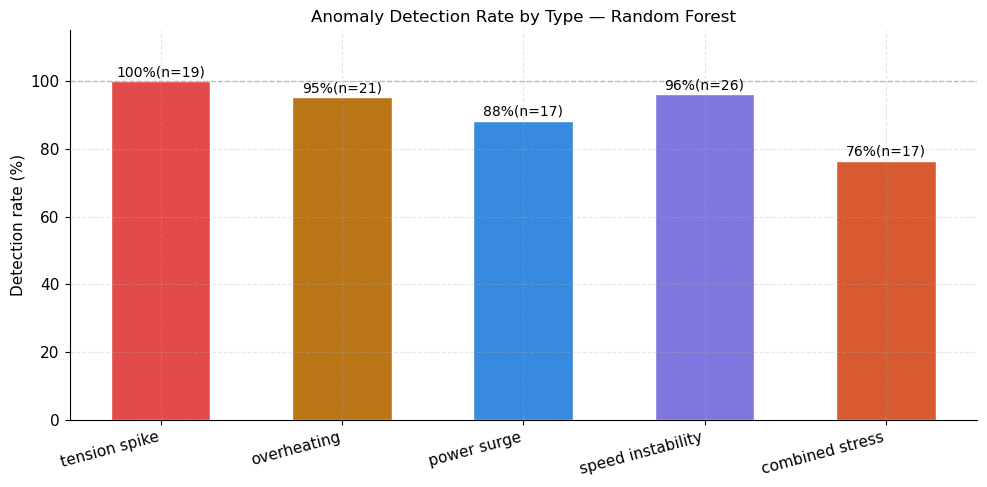

Saved: 10_detection_rate_by_type.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

detection_rates = []
counts = []
for atype in ANOMALY_TYPES:
    mask     = df['anomaly_type'] == atype
    total    = mask.sum()
    detected = y_pred[mask].sum()
    rate     = detected / total * 100
    detection_rates.append(rate)
    counts.append(total)
    print(f"  {atype:<22} : {detected:>2}/{total} detected  ({rate:.1f}%)")

colors = ['#E24B4A','#BA7517','#378ADD','#7F77DD','#D85A30']
bars = ax.bar(ANOMALY_TYPES, detection_rates,
              color=colors, edgecolor='white', width=0.55)

for bar, rate, count in zip(bars, detection_rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{rate:.0f}%(n={count})',
            ha='center', fontsize=10)

ax.set_ylabel('Detection rate (%)')
ax.set_title('Anomaly Detection Rate by Type — Random Forest')
ax.set_ylim(0, 115)
ax.axhline(100, color='#888780', lw=1, linestyle='--', alpha=0.5)
ax.set_xticklabels([t.replace('_', ' ') for t in ANOMALY_TYPES], rotation=15, ha='right')

plt.tight_layout()
plt.savefig('../results/plots/10_detection_rate_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_detection_rate_by_type.png")


## 3. Feature Importance per Anomaly Type

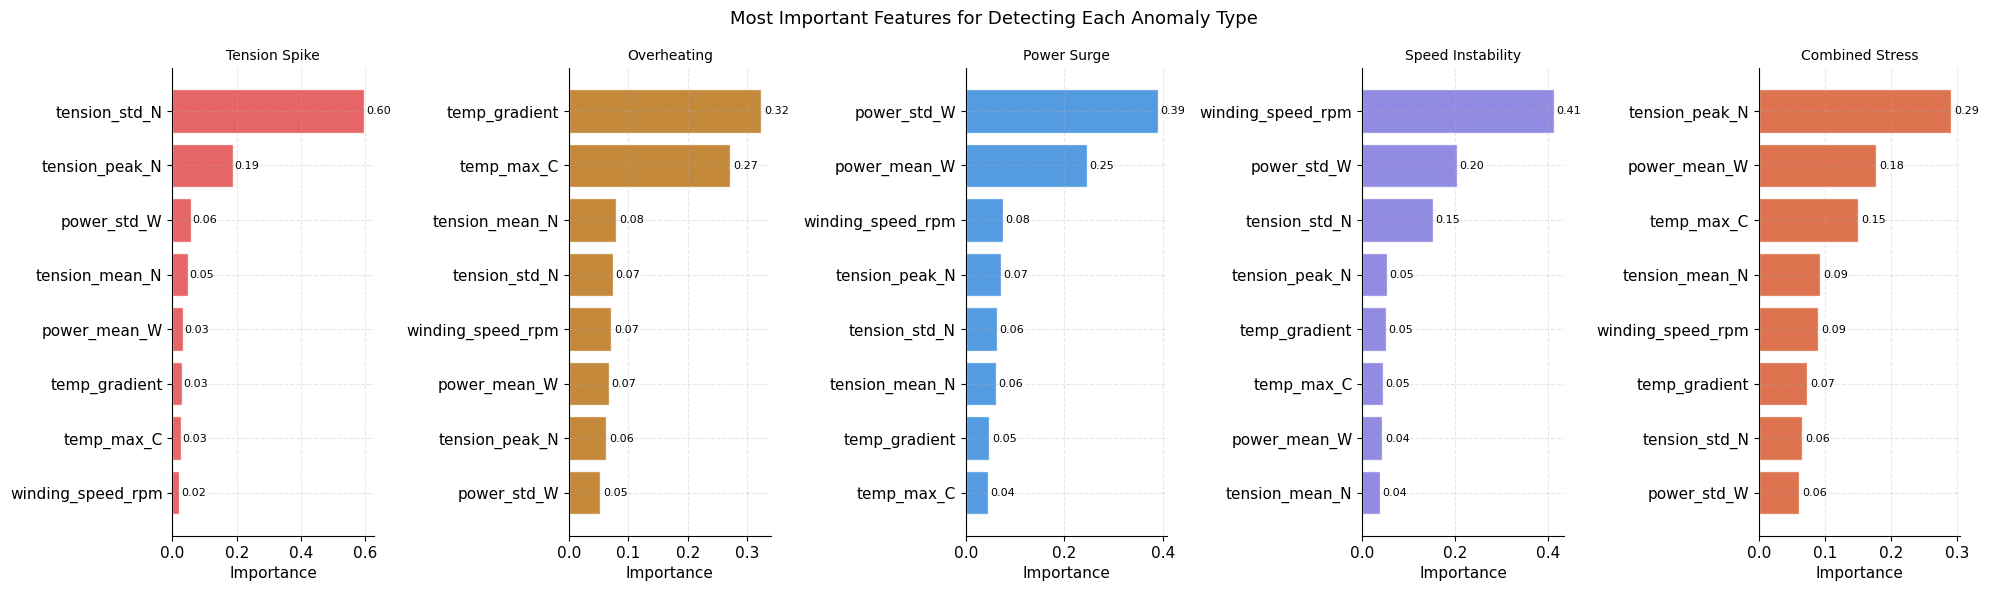

Saved: 11_feature_importance_by_type.png


In [6]:
fig, axes = plt.subplots(1, len(ANOMALY_TYPES), figsize=(20, 6))
fig.suptitle('Most Important Features for Detecting Each Anomaly Type', fontsize=13)

colors = ['#E24B4A','#BA7517','#378ADD','#7F77DD','#D85A30']

importances_all = {}

for ax, atype, color in zip(axes, ANOMALY_TYPES, colors):
    # Binary classification: this anomaly type vs normal
    mask_type   = (df['anomaly_type'] == atype)
    mask_normal = (df['anomaly_type'] == 'normal')
    mask_use    = mask_type | mask_normal

    X_sub = X_scaled[mask_use]
    y_sub = (df['anomaly_type'][mask_use] == atype).astype(int).values

    rf_sub = RandomForestClassifier(
        n_estimators=100, max_depth=8,
        class_weight='balanced', random_state=SEED
    )
    rf_sub.fit(X_sub, y_sub)

    imp = pd.Series(rf_sub.feature_importances_, index=SIGNAL_FEATURES)
    imp = imp.sort_values(ascending=True)
    importances_all[atype] = imp

    bars = ax.barh(imp.index, imp.values, color=color,
                   edgecolor='white', alpha=0.85)
    ax.set_title(atype.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Importance')
    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/11_feature_importance_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 11_feature_importance_by_type.png")


## 4. Top Feature per Anomaly Type — Summary

In [20]:
print("Top 3 important features per anomaly type:")
print("=" * 55)
for atype in ANOMALY_TYPES:
    top3 = importances_all[atype].sort_values(ascending=False).head(3)
    print(f"{atype.replace('_',' ').upper()}")
    for feat, val in top3.items():
        print(f"    {feat:<25} importance = {val:.3f}")


Top 3 important features per anomaly type:
TENSION SPIKE
    tension_std_N             importance = 0.598
    tension_peak_N            importance = 0.188
    power_std_W               importance = 0.057
OVERHEATING
    temp_gradient             importance = 0.323
    temp_max_C                importance = 0.271
    tension_mean_N            importance = 0.079
POWER SURGE
    power_std_W               importance = 0.389
    power_mean_W              importance = 0.246
    winding_speed_rpm         importance = 0.075
SPEED INSTABILITY
    winding_speed_rpm         importance = 0.414
    power_std_W               importance = 0.204
    tension_std_N             importance = 0.152
COMBINED STRESS
    tension_peak_N            importance = 0.291
    power_mean_W              importance = 0.177
    temp_max_C                importance = 0.150


## 5. Misclassified Samples Analysis

In [9]:
# Find samples the model got wrong
wrong_mask  = y_pred != y
correct_mask = y_pred == y

print(f"Total misclassified : {wrong_mask.sum()} / {len(y)}")
print(f"False positives     : {((y_pred==1) & (y==0)).sum()} (normal flagged as anomaly)")
print(f"False negatives     : {((y_pred==0) & (y==1)).sum()} (anomaly missed)")
print()

# Which anomaly types were missed most
print("Missed anomalies by type (false negatives):")
fn_mask = (y_pred == 0) & (y == 1)
missed_types = df[fn_mask]['anomaly_type'].value_counts()
for atype, count in missed_types.items():
    total = (df['anomaly_type'] == atype).sum()
    print(f"  {atype:<22} : {count} missed out of {total} ({count/total*100:.1f}%)")


Total misclassified : 14 / 500
False positives     : 6 (normal flagged as anomaly)
False negatives     : 8 (anomaly missed)

Missed anomalies by type (false negatives):
  combined_stress        : 4 missed out of 17 (23.5%)
  power_surge            : 2 missed out of 17 (11.8%)
  overheating            : 1 missed out of 21 (4.8%)
  speed_instability      : 1 missed out of 26 (3.8%)


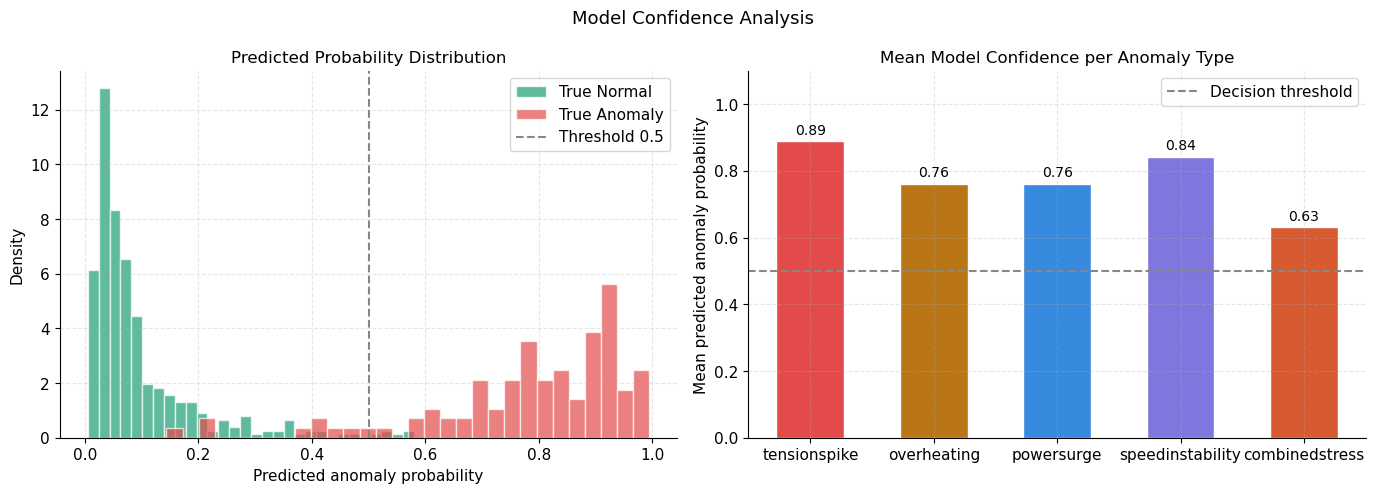

Saved: 12_confidence_analysis.png


In [13]:
# Plot: anomaly probability distribution for correct vs wrong predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Confidence Analysis', fontsize=13)

# Left: probability distribution by true label
ax = axes[0]
ax.hist(y_proba[y==0], bins=30, alpha=0.7, color='#1D9E75',
        edgecolor='white', label='True Normal', density=True)
ax.hist(y_proba[y==1], bins=30, alpha=0.7, color='#E24B4A',
        edgecolor='white', label='True Anomaly', density=True)
ax.axvline(0.5, color='#888780', lw=1.5, linestyle='--', label='Threshold 0.5')
ax.set_xlabel('Predicted anomaly probability')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution')
ax.legend()

# Right: mean probability per anomaly type
ax = axes[1]
mean_proba = []
for atype in ANOMALY_TYPES:
    mask = df['anomaly_type'] == atype
    mean_proba.append(y_proba[mask].mean())

colors_bar = ['#E24B4A','#BA7517','#378ADD','#7F77DD','#D85A30']
bars = ax.bar([t.replace('_','') for t in ANOMALY_TYPES],mean_proba, color=colors_bar, edgecolor='white', width=0.55)
ax.axhline(0.5, color='#888780', lw=1.5, linestyle='--', label='Decision threshold')
ax.set_ylabel('Mean predicted anomaly probability')
ax.set_title('Mean Model Confidence per Anomaly Type')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, mean_proba):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.02,
            f'{val:.2f}', ha='center', fontsize=10)
ax.legend()

plt.tight_layout()
plt.savefig('../results/plots/12_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 12_confidence_analysis.png")


## 6. Final Summary

In [26]:
print("=" * 55)
print("ANOMALY DIAGNOSIS SUMMARY")
print("=" * 55)

print("\nDETECTION RATES BY ANOMALY TYPE:")
for atype in ANOMALY_TYPES:
    mask     = df['anomaly_type'] == atype
    total    = mask.sum()
    detected = y_pred[mask].sum()
    rate     = detected / total * 100
    print(f"  {atype:<22} : {detected}/{total}  ({rate:.1f}%)")

print("\nTOP SIGNAL PER ANOMALY TYPE:")
for atype in ANOMALY_TYPES:
    top = importances_all[atype].sort_values(ascending=False).index[0]
    print(f"  {atype:<22} : {top}")

wrong = (y_pred != y).sum()
fp    = ((y_pred==1) & (y==0)).sum()
fn    = ((y_pred==0) & (y==1)).sum()

print(f"\nMODEL ERRORS:")
print(f"  Total misclassified : {wrong} / {len(y)}")
print(f"  False positives     : {fp}  (normal cycles flagged as anomaly)")
print(f"  False negatives     : {fn}  (anomaly cycles missed)")


ANOMALY DIAGNOSIS SUMMARY

DETECTION RATES BY ANOMALY TYPE:
  tension_spike          : 19/19  (100.0%)
  overheating            : 20/21  (95.2%)
  power_surge            : 15/17  (88.2%)
  speed_instability      : 25/26  (96.2%)
  combined_stress        : 13/17  (76.5%)

TOP SIGNAL PER ANOMALY TYPE:
  tension_spike          : tension_std_N
  overheating            : temp_gradient
  power_surge            : power_std_W
  speed_instability      : winding_speed_rpm
  combined_stress        : tension_peak_N

MODEL ERRORS:
  Total misclassified : 14 / 500
  False positives     : 6  (normal cycles flagged as anomaly)
  False negatives     : 8  (anomaly cycles missed)
